## **0. Setup & Import Libraries**

In [20]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# ── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

# ── Styling ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250',
    'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',
    'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',
    'grid.color': '#2e3250',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans',
})

# ── Color Palette (consistent across notebook) ───────────────────────────────
PALETTE = {
    'alphabet':  '#4cc9f0',
    'number':    '#f72585',
    'affix':     '#7209b7',
    'sentences': '#4361ee',
}
GRAD_PALETTE = ['#4cc9f0', '#4361ee', '#7209b7', '#f72585']

print('✅ Libraries loaded successfully')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')

✅ Libraries loaded successfully
   pandas  : 2.1.4
   numpy   : 1.26.4


## **1. Load All Metadata Files**

In [21]:
# ── Sesuaikan path ke lokasi file CSV kamu ────────────────────────────────────
BASE_DIR = '../data/metadata/'   # ganti jika file ada di folder lain, misal './data/metadata/'

META_FILES = {
    'alphabet' : os.path.join(BASE_DIR, 'Metadata_alphabet.csv'),
    'number'   : os.path.join(BASE_DIR, 'Metadata_number.csv'),
    'affix'    : os.path.join(BASE_DIR, 'Metadata_affix.csv'),
    'sentences': os.path.join(BASE_DIR, 'Metadata_sentences.csv'),
}

dfs = {}
for name, path in META_FILES.items():
    if os.path.exists(path):
        dfs[name] = pd.read_csv(path)
        dfs[name]['__source__'] = name          # tag asal dataset
        print(f'  ✅ [{name:10s}] loaded — shape: {dfs[name].shape}')
    else:
        print(f'  ❌ [{name:10s}] FILE NOT FOUND → {path}')

print(f'\n📦 Total datasets loaded: {len(dfs)}')

  ✅ [alphabet  ] loaded — shape: (520, 12)
  ✅ [number    ] loaded — shape: (776, 12)
  ✅ [affix     ] loaded — shape: (360, 12)
  ✅ [sentences ] loaded — shape: (1400, 13)

📦 Total datasets loaded: 4


## **2. Class Distribution per Dataset**

In [22]:
# ── DETEKSI KOLOM LABEL ───────────────────────────────────────────────────────
# Sesuaikan nama kolom label jika berbeda di dataset kamu
LABEL_COL_CANDIDATES = ['label', 'class', 'gloss', 'word', 'sign', 'gesture',
                         'kata', 'kelas', 'Label', 'Class', 'Gloss']

label_cols = {}
for name, df in dfs.items():
    found = [c for c in LABEL_COL_CANDIDATES if c in df.columns]
    label_cols[name] = found[0] if found else df.columns[0]
    print(f'  [{name:10s}] → label column detected: "{label_cols[name]}"')

  [alphabet  ] → label column detected: "sign"
  [number    ] → label column detected: "sign"
  [affix     ] → label column detected: "sign"
  [sentences ] → label column detected: "signer"


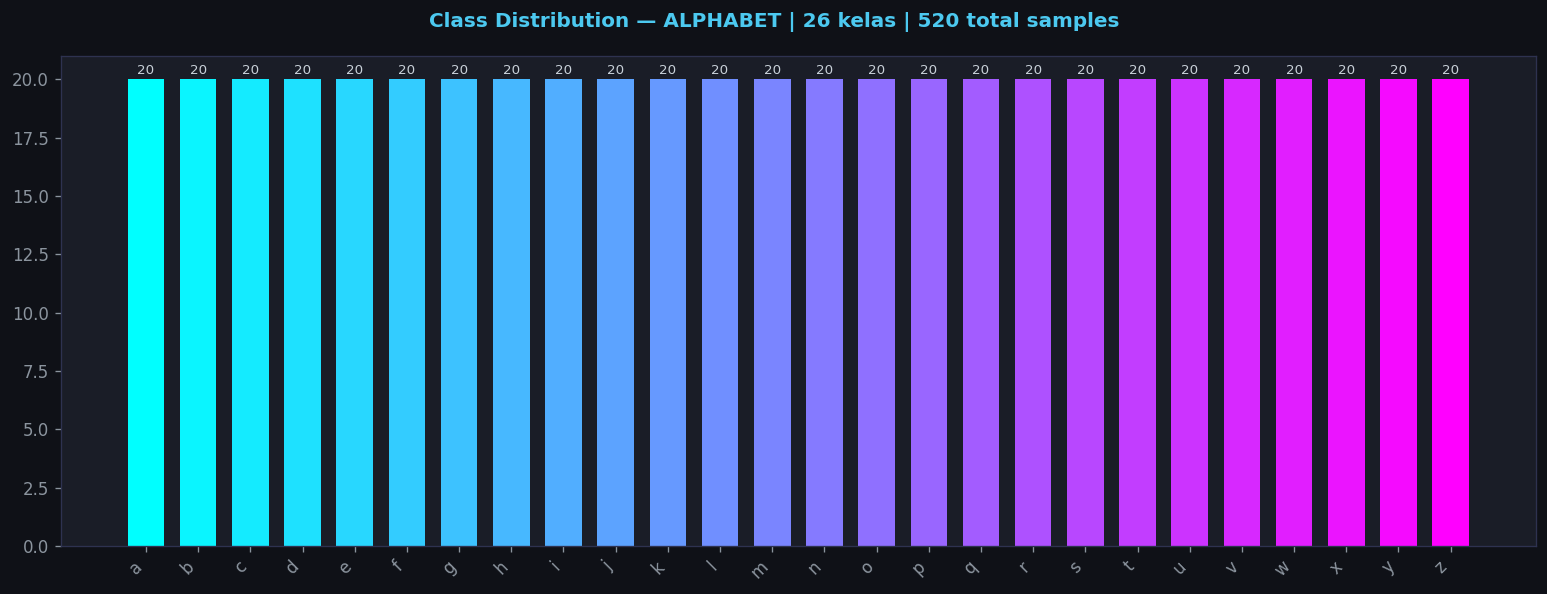

  [ALPHABET] Class Balance Stats:
    Min samples/class : 20
    Max samples/class : 20
    Mean              : 20.00
    Std               : 0.00
    Imbalance Ratio   : 1.00x



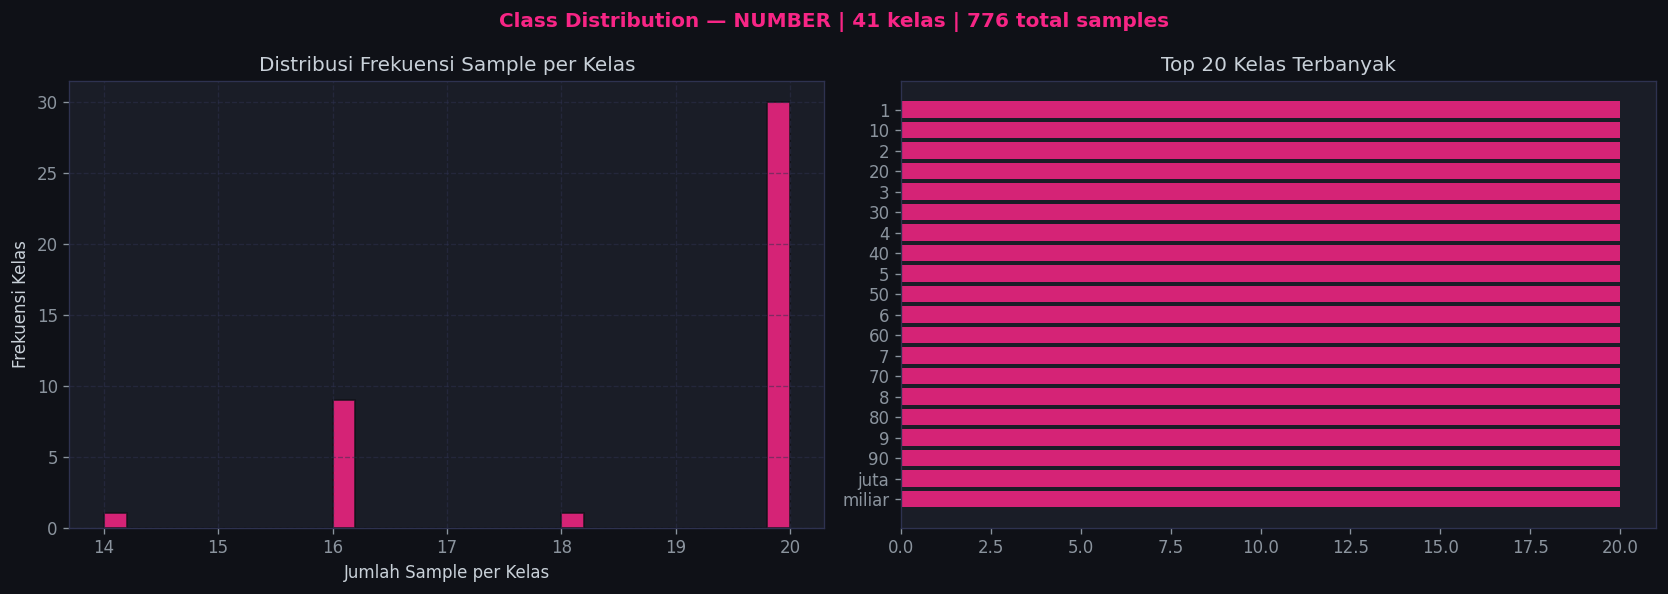

  [NUMBER] Class Balance Stats:
    Min samples/class : 14
    Max samples/class : 20
    Mean              : 18.93
    Std               : 1.85
    Imbalance Ratio   : 1.43x



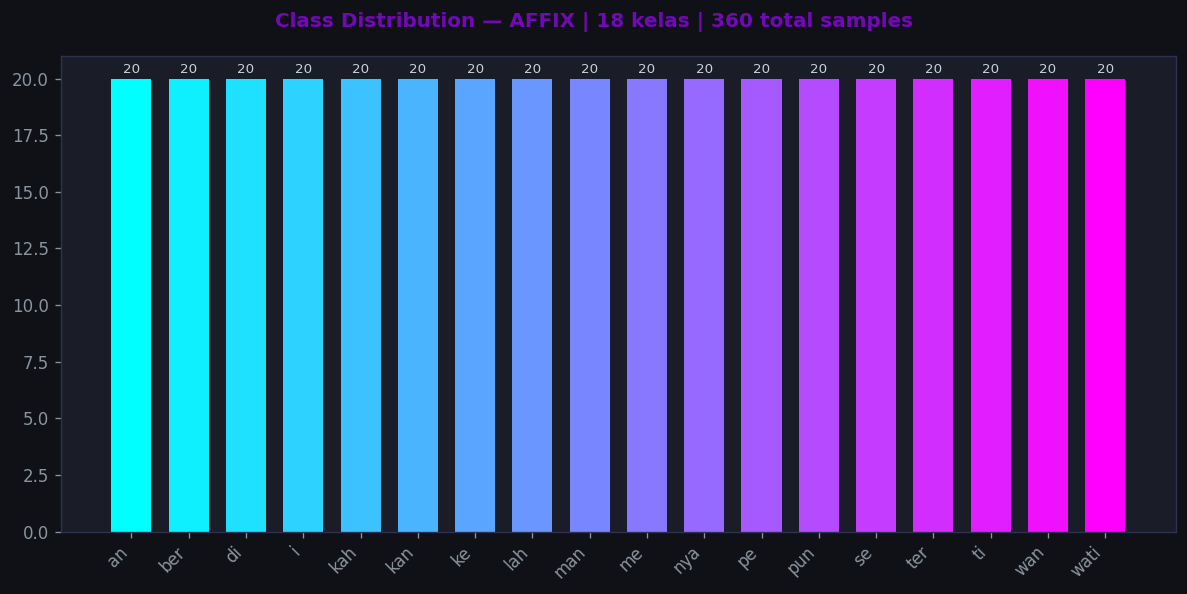

  [AFFIX] Class Balance Stats:
    Min samples/class : 20
    Max samples/class : 20
    Mean              : 20.00
    Std               : 0.00
    Imbalance Ratio   : 1.00x



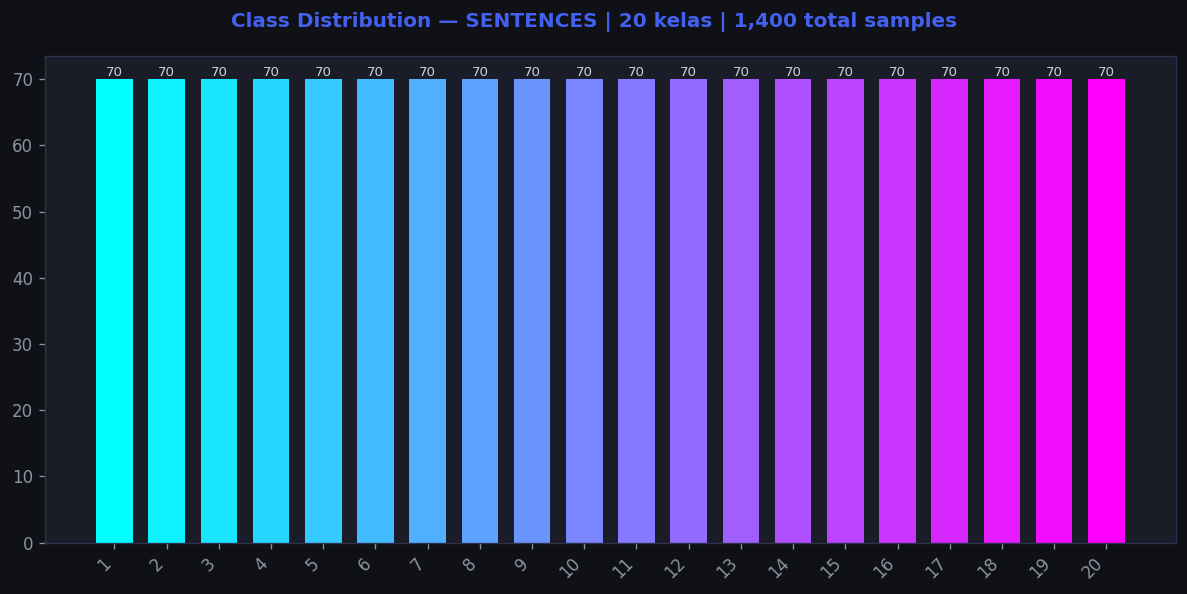

  [SENTENCES] Class Balance Stats:
    Min samples/class : 70
    Max samples/class : 70
    Mean              : 70.00
    Std               : 0.00
    Imbalance Ratio   : 1.00x



In [23]:
# ── Plot class distribution ───────────────────────────────────────────────────
for name, df in dfs.items():
    lbl = label_cols[name]
    vc  = df[lbl].value_counts().sort_index()
    n_classes = len(vc)

    # Tentukan layout berdasarkan jumlah kelas
    if n_classes <= 30:
        fig, ax = plt.subplots(figsize=(max(10, n_classes * 0.5), 5))
        colors = plt.cm.cool(np.linspace(0, 1, n_classes))
        bars = ax.bar(vc.index.astype(str), vc.values, color=colors, edgecolor='none', width=0.7)
        ax.set_xticklabels(vc.index.astype(str), rotation=45 if n_classes > 15 else 0, ha='right')
        # Annotasi nilai di atas bar
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,\
                    int(bar.get_height()), ha='center', va='bottom', fontsize=8, color='#c9d1d9')
    else:
        # Untuk kelas banyak: histogram distribusi frekuensi
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        ax1.hist(vc.values, bins=30, color=PALETTE[name], edgecolor='#0f1117', alpha=0.85)
        ax1.set_title('Distribusi Frekuensi Sample per Kelas', color='#c9d1d9')
        ax1.set_xlabel('Jumlah Sample per Kelas')
        ax1.set_ylabel('Frekuensi Kelas')
        ax1.grid(True)

        # Top 20 dan Bottom 20 kelas
        top20 = vc.nlargest(20)
        ax2.barh(top20.index.astype(str), top20.values, color=PALETTE[name], alpha=0.85)
        ax2.set_title('Top 20 Kelas Terbanyak', color='#c9d1d9')
        ax2.invert_yaxis()
        ax = ax1

    fig.suptitle(f'Class Distribution — {name.upper()} | {n_classes} kelas | {len(df):,} total samples',
                 fontsize=12, fontweight='bold', color=PALETTE[name])
    plt.tight_layout()
    plt.savefig(f'eda_02_class_dist_{name}.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

    # ── Stats ringkasan ──────────────────────────────────────────────────────
    print(f'  [{name.upper()}] Class Balance Stats:')
    print(f'    Min samples/class : {vc.min()}')
    print(f'    Max samples/class : {vc.max()}')
    print(f'    Mean              : {vc.mean():.2f}')
    print(f'    Std               : {vc.std():.2f}')
    print(f'    Imbalance Ratio   : {vc.max()/vc.min():.2f}x')
    print()

## **3. Cross-Dataset Overview: Sample Count & Class Count Comparison**


── Dataset Overview Summary ────────────────────────────────────────


,Total Samples,Num Classes,Columns,Avg Samples/Class
Dataset,,,,
alphabet,520,26,11,20.00
number,776,41,11,18.93
affix,360,18,11,20.00
sentences,1400,20,12,70.00


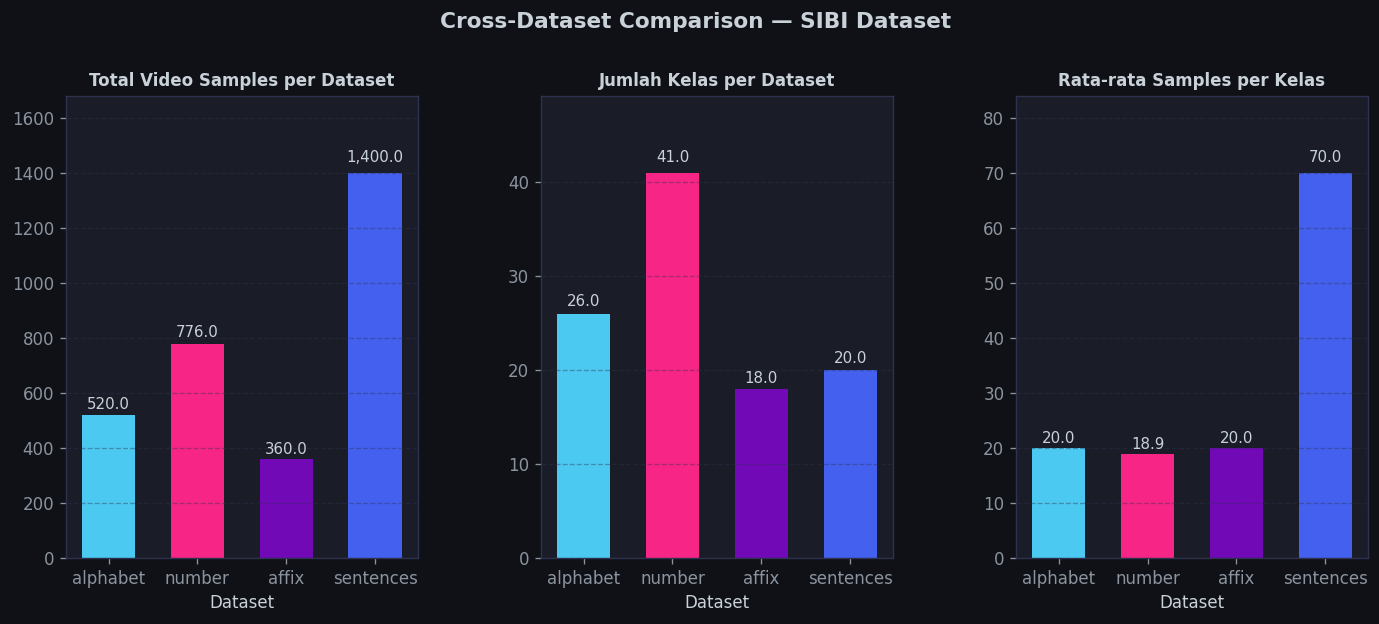

In [24]:
summary = pd.DataFrame({
    'Dataset'      : list(dfs.keys()),
    'Total Samples': [len(df) for df in dfs.values()],
    'Num Classes'  : [df[label_cols[n]].nunique() for n, df in dfs.items()],
    'Columns'      : [df.shape[1]-1 for df in dfs.values()],  # -1 for __source__
})
summary['Avg Samples/Class'] = (summary['Total Samples'] / summary['Num Classes']).round(2)

print('\n── Dataset Overview Summary ────────────────────────────────────────')
display(summary.set_index('Dataset'))

# ── Visualisasi comparison ────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 5))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

metrics = [\
    ('Total Samples',      'Total Video Samples per Dataset',    '#4cc9f0'),
    ('Num Classes',        'Jumlah Kelas per Dataset',           '#f72585'),
    ('Avg Samples/Class',  'Rata-rata Samples per Kelas',        '#7209b7'),
]

for i, (col, title, color) in enumerate(metrics):
    ax = fig.add_subplot(gs[i])
    colors = [PALETTE[d] for d in summary['Dataset']]
    bars = ax.bar(summary['Dataset'], summary[col], color=colors, edgecolor='none', width=0.6)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,\
                f'{bar.get_height():,.1f}', ha='center', va='bottom', fontsize=9, color='#c9d1d9')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Dataset')
    ax.grid(axis='y', alpha=0.4)
    ax.set_ylim(0, summary[col].max() * 1.2)

fig.suptitle('Cross-Dataset Comparison — SIBI Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.savefig('eda_03_cross_dataset.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## **4. Gesture Type Analysis: Static vs Dynamic**


── Static vs Dynamic Gesture Summary ───────────────────────────────


'Gesture Type  Total_Samples  Total_Classes         Datasets\n     Dynamic           1760             38 affix, sentences\n      Static           1296             67 alphabet, number'

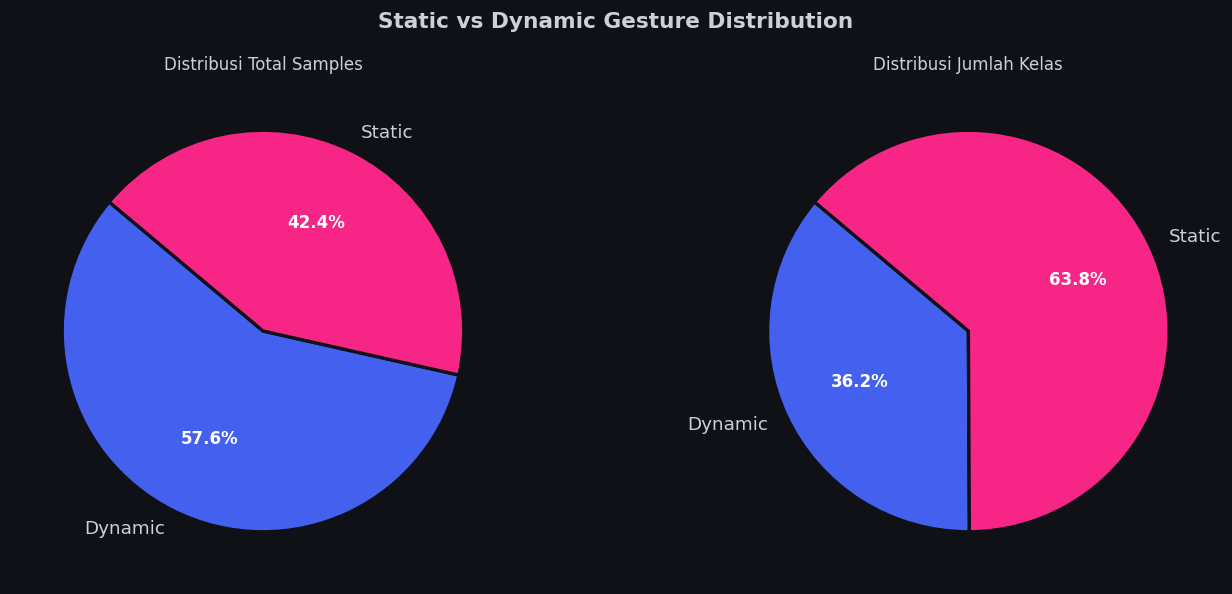

In [25]:
# Kategorisasi berdasarkan jenis gestur (sesuai paper Al-Hammadi et al.)
# - Static  : alphabet (fingerspelling), number → fixed finger config
# - Dynamic : affix, sentences → melibatkan pergerakan

gesture_type_map = {
    'alphabet' : 'Static',
    'number'   : 'Static',
    'affix'    : 'Dynamic',
    'sentences': 'Dynamic',
}

summary['Gesture Type'] = summary['Dataset'].map(gesture_type_map)

type_summary = summary.groupby('Gesture Type').agg(
    Total_Samples=('Total Samples', 'sum'),
    Total_Classes=('Num Classes', 'sum'),
    Datasets=('Dataset', lambda x: ', '.join(x))
).reset_index()

print('\n── Static vs Dynamic Gesture Summary ───────────────────────────────')
display(type_summary.to_string(index=False))

# ── Pie chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Static vs Dynamic Gesture Distribution', fontsize=13, fontweight='bold')

pie_colors = ['#4361ee', '#f72585']

for ax, col, title in zip(axes,
                           ['Total_Samples', 'Total_Classes'],
                           ['Distribusi Total Samples', 'Distribusi Jumlah Kelas']):
    wedges, texts, autotexts = ax.pie(
        type_summary[col],
        labels=type_summary['Gesture Type'],
        autopct='%1.1f%%',
        colors=pie_colors,
        startangle=140,
        wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2},
        textprops={'color': '#c9d1d9', 'fontsize': 11}
    )
    for at in autotexts:
        at.set_fontsize(10)
        at.set_color('white')
        at.set_fontweight('bold')
    ax.set_title(title, fontsize=10, color='#c9d1d9')

plt.tight_layout()
plt.savefig('eda_04_static_vs_dynamic.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## **5. Signer / Participant Analysis**

In [26]:
# ── Deteksi kolom signer ──────────────────────────────────────────────────────
SIGNER_COL_CANDIDATES = ['signer', 'signer_id', 'participant', 'subject',
                          'person', 'performer', 'user', 'id_signer']

signer_cols = {}
for name, df in dfs.items():
    found = [c for c in SIGNER_COL_CANDIDATES if c.lower() in [col.lower() for col in df.columns]]
    if found:
        # Match case-insensitive
        matched = [col for col in df.columns if col.lower() == found[0].lower()]
        signer_cols[name] = matched[0]
    else:
        signer_cols[name] = None

print('Signer column detection:')
for name, col in signer_cols.items():
    print(f'  [{name:10s}] → {col if col else "NOT FOUND — skip"}')

Signer column detection:
  [alphabet  ] → signer
  [number    ] → signer
  [affix     ] → signer
  [sentences ] → signer


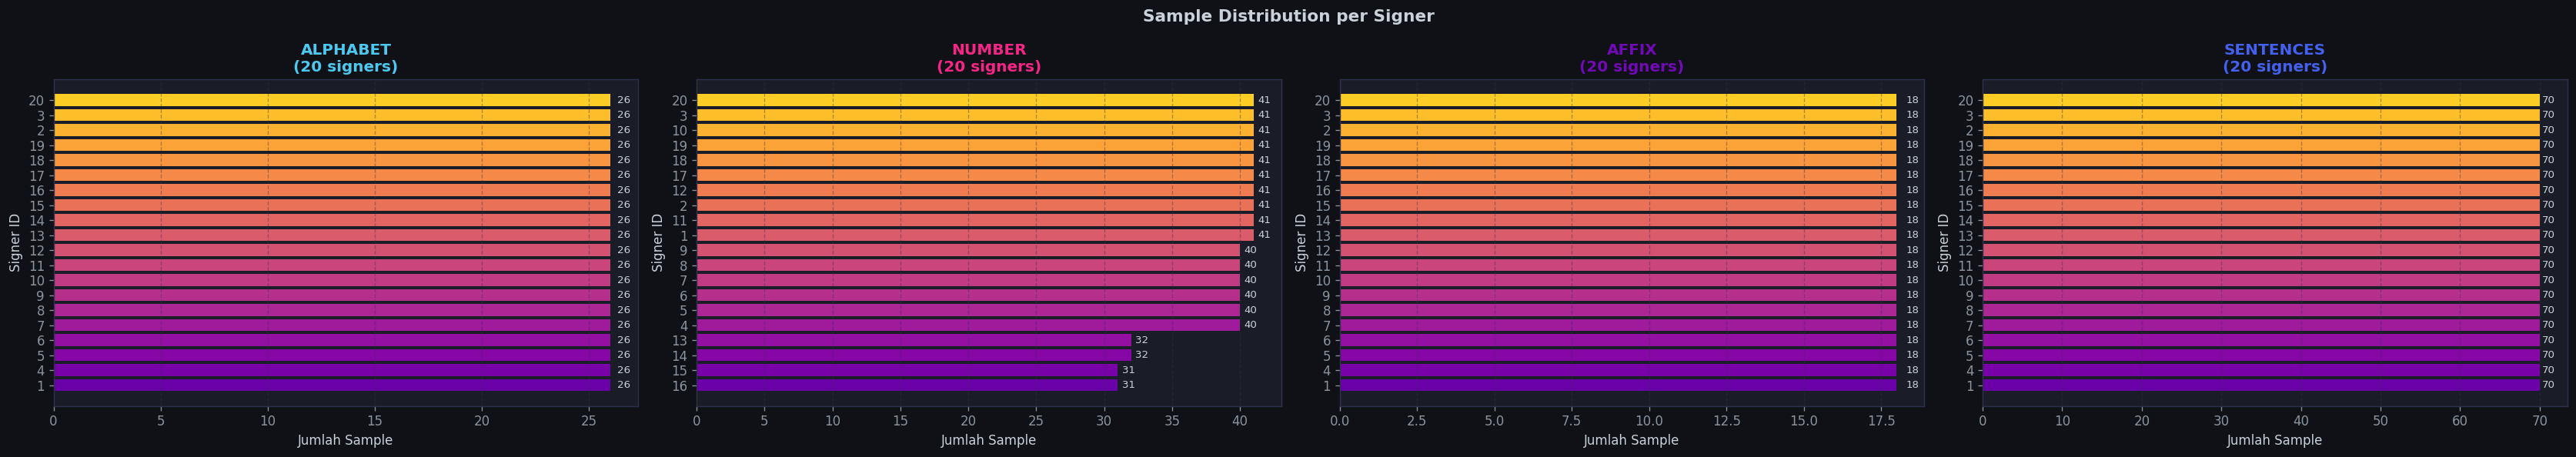


── Signer Coverage per Class (heatmap) ────────────────────────────


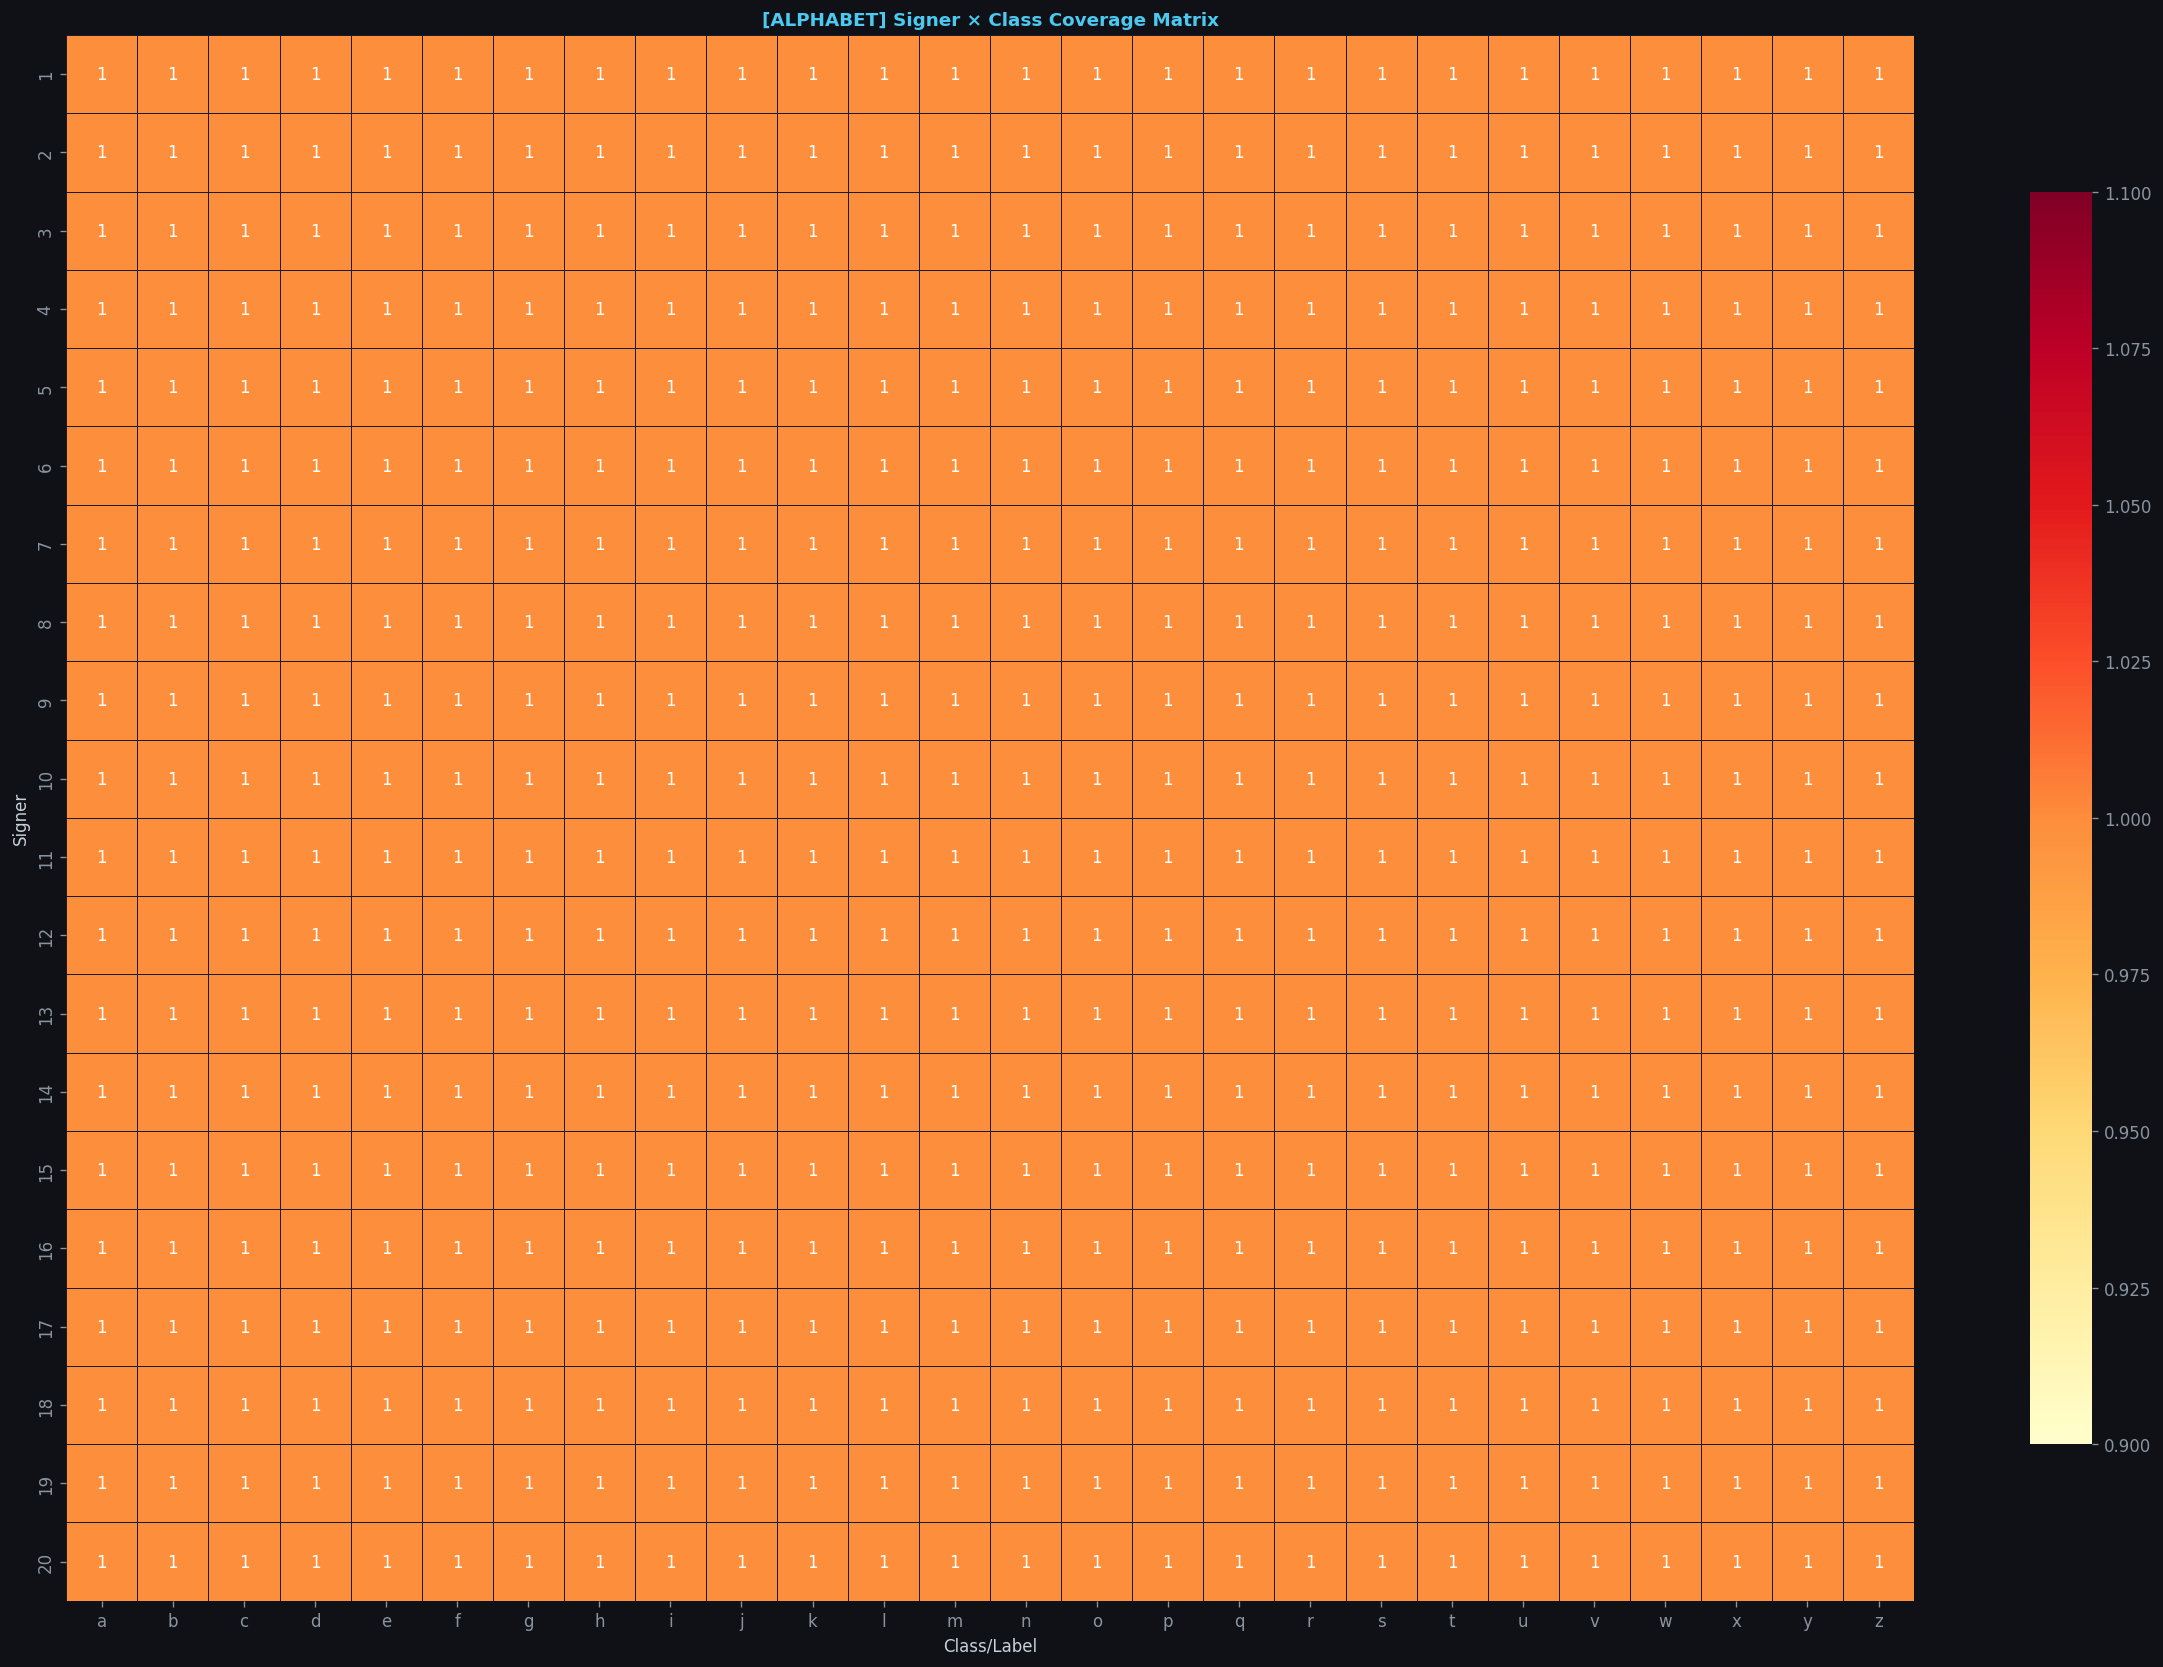

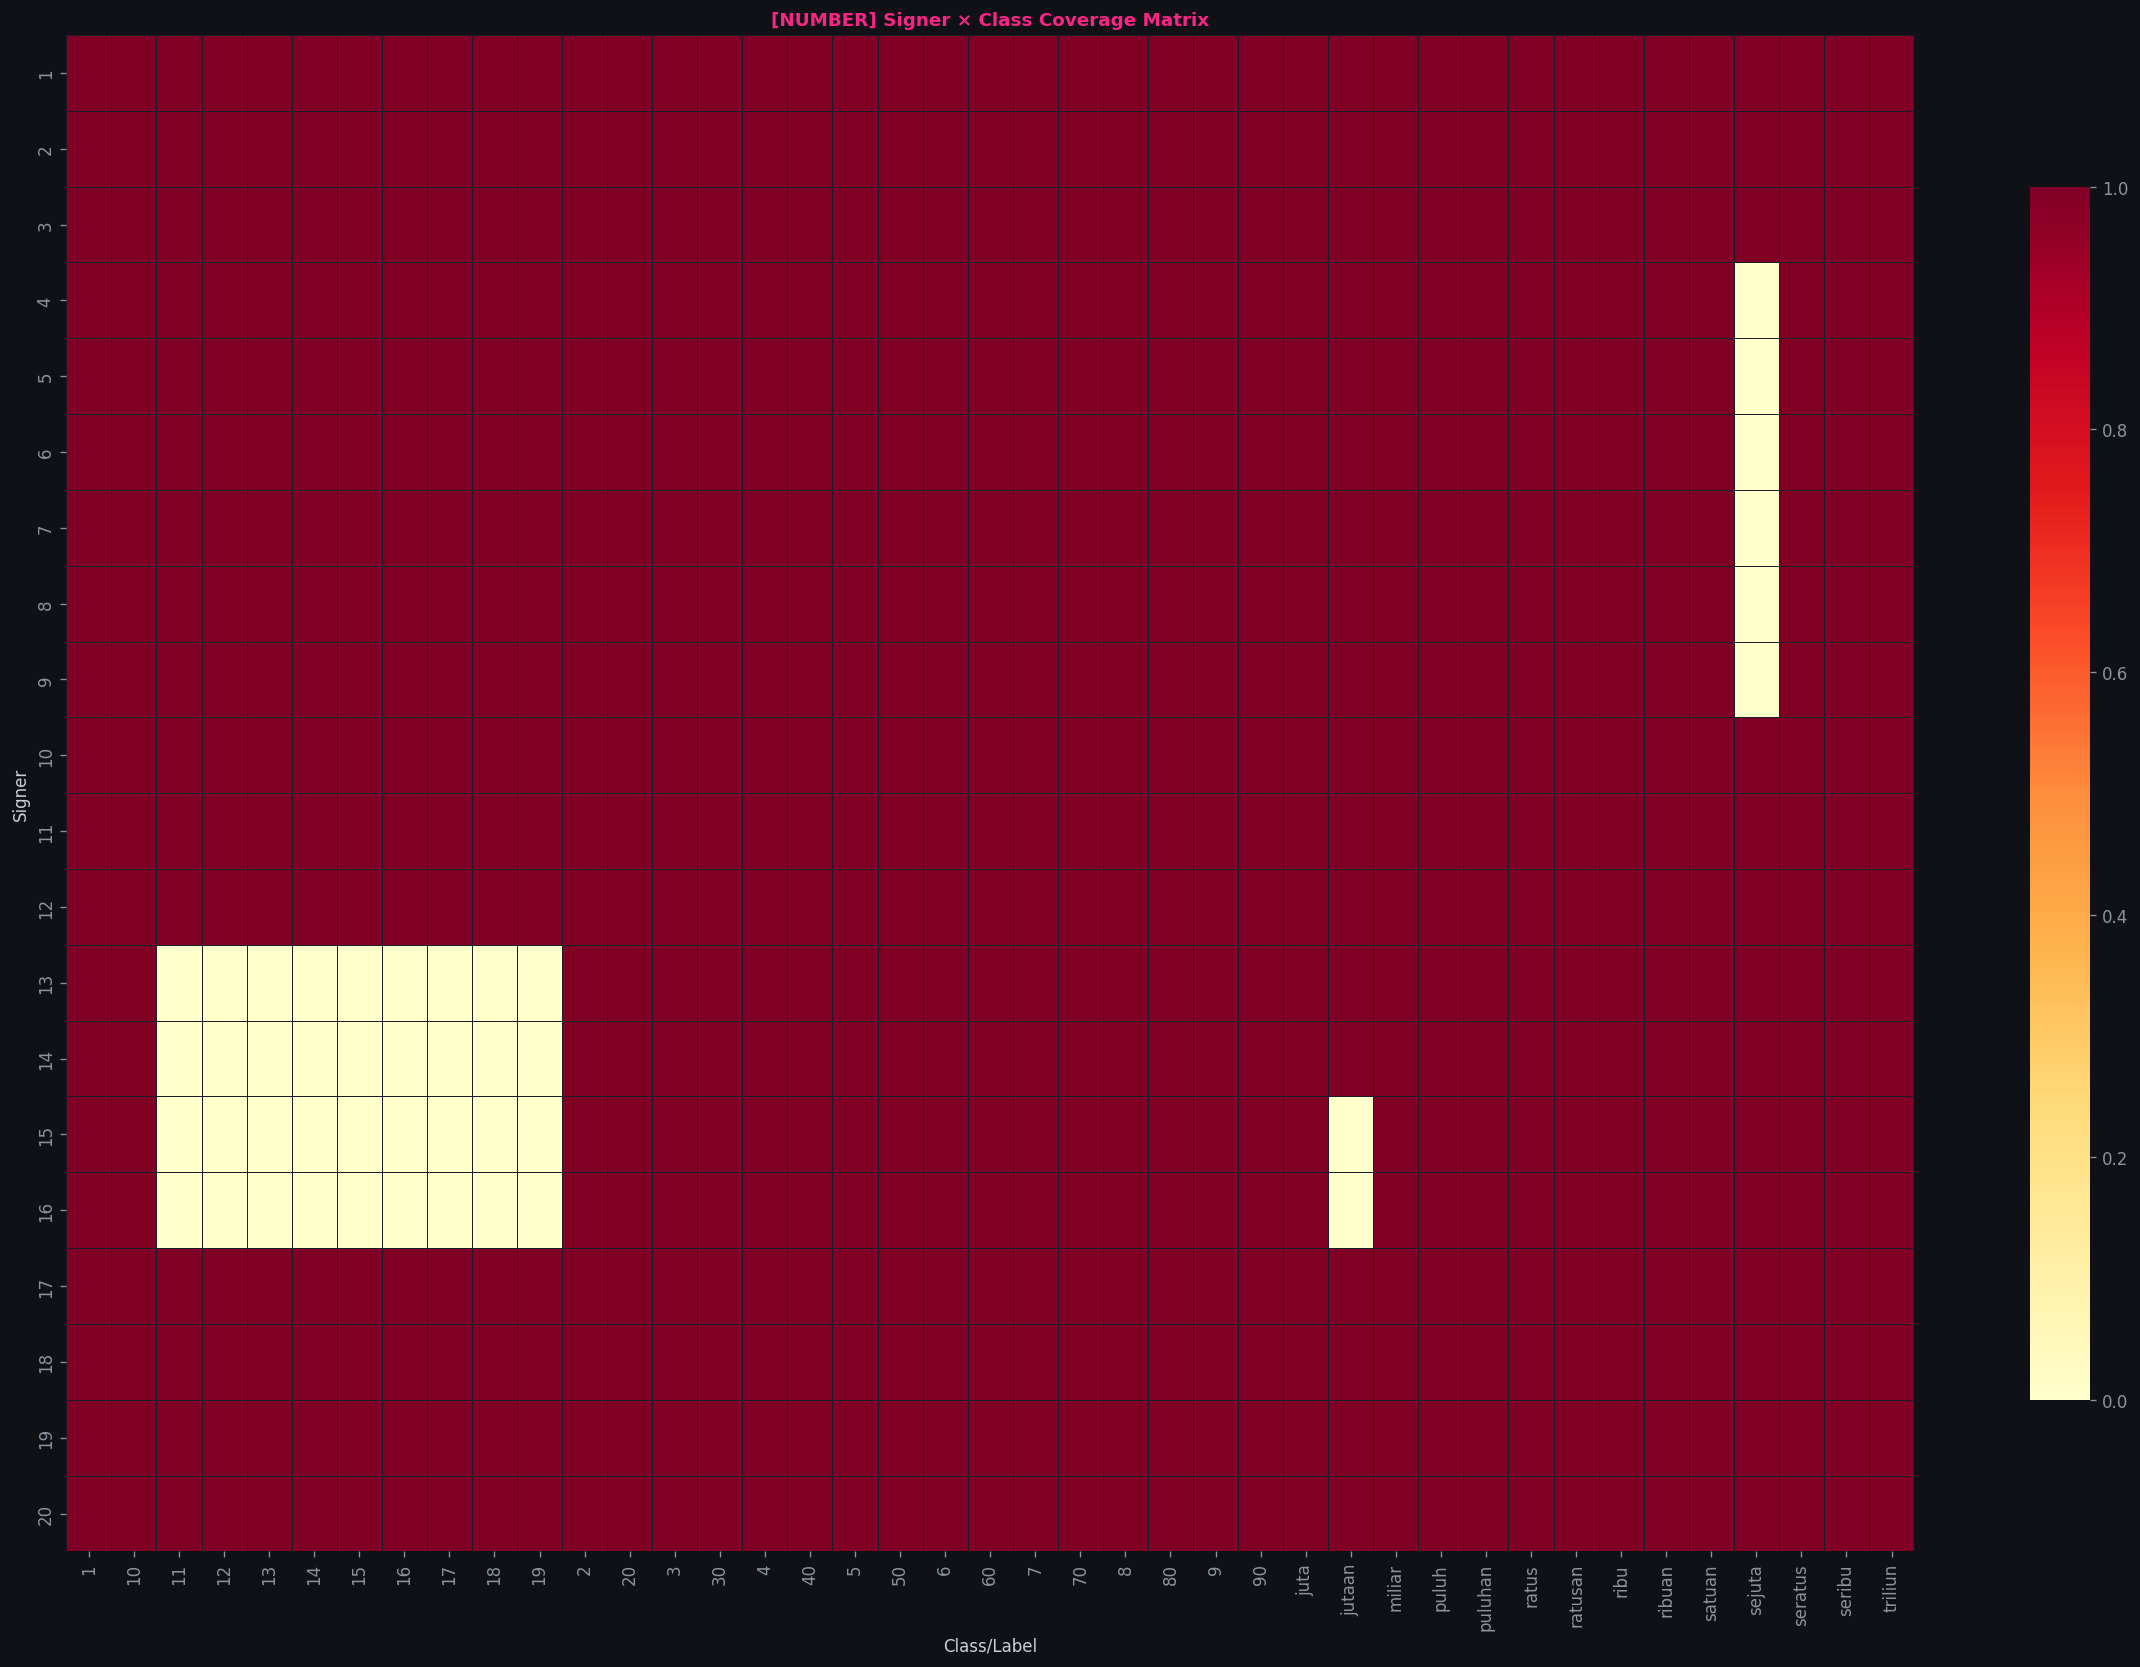

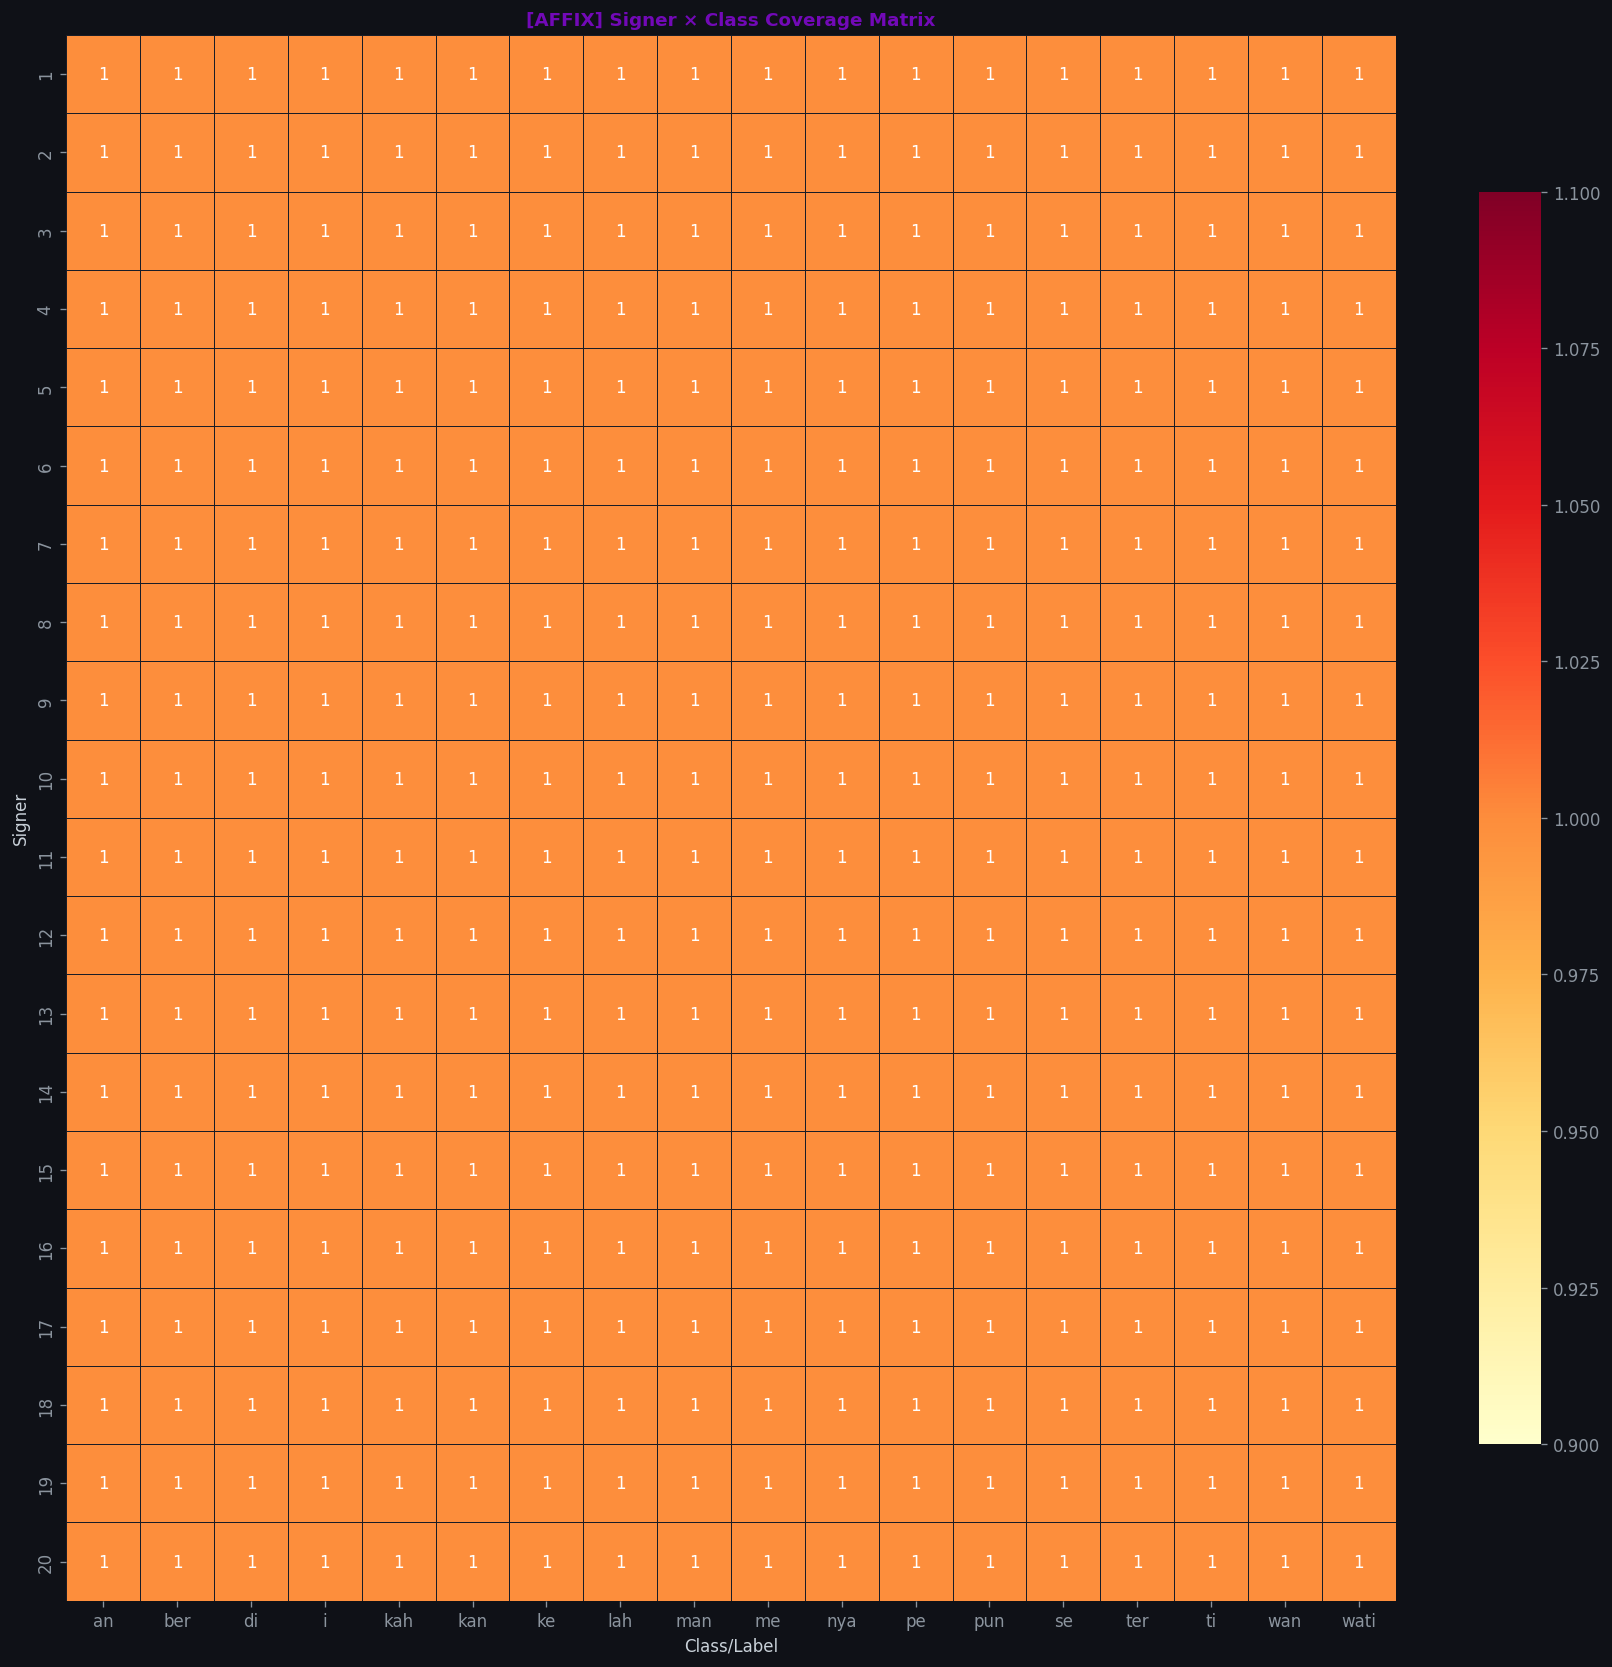

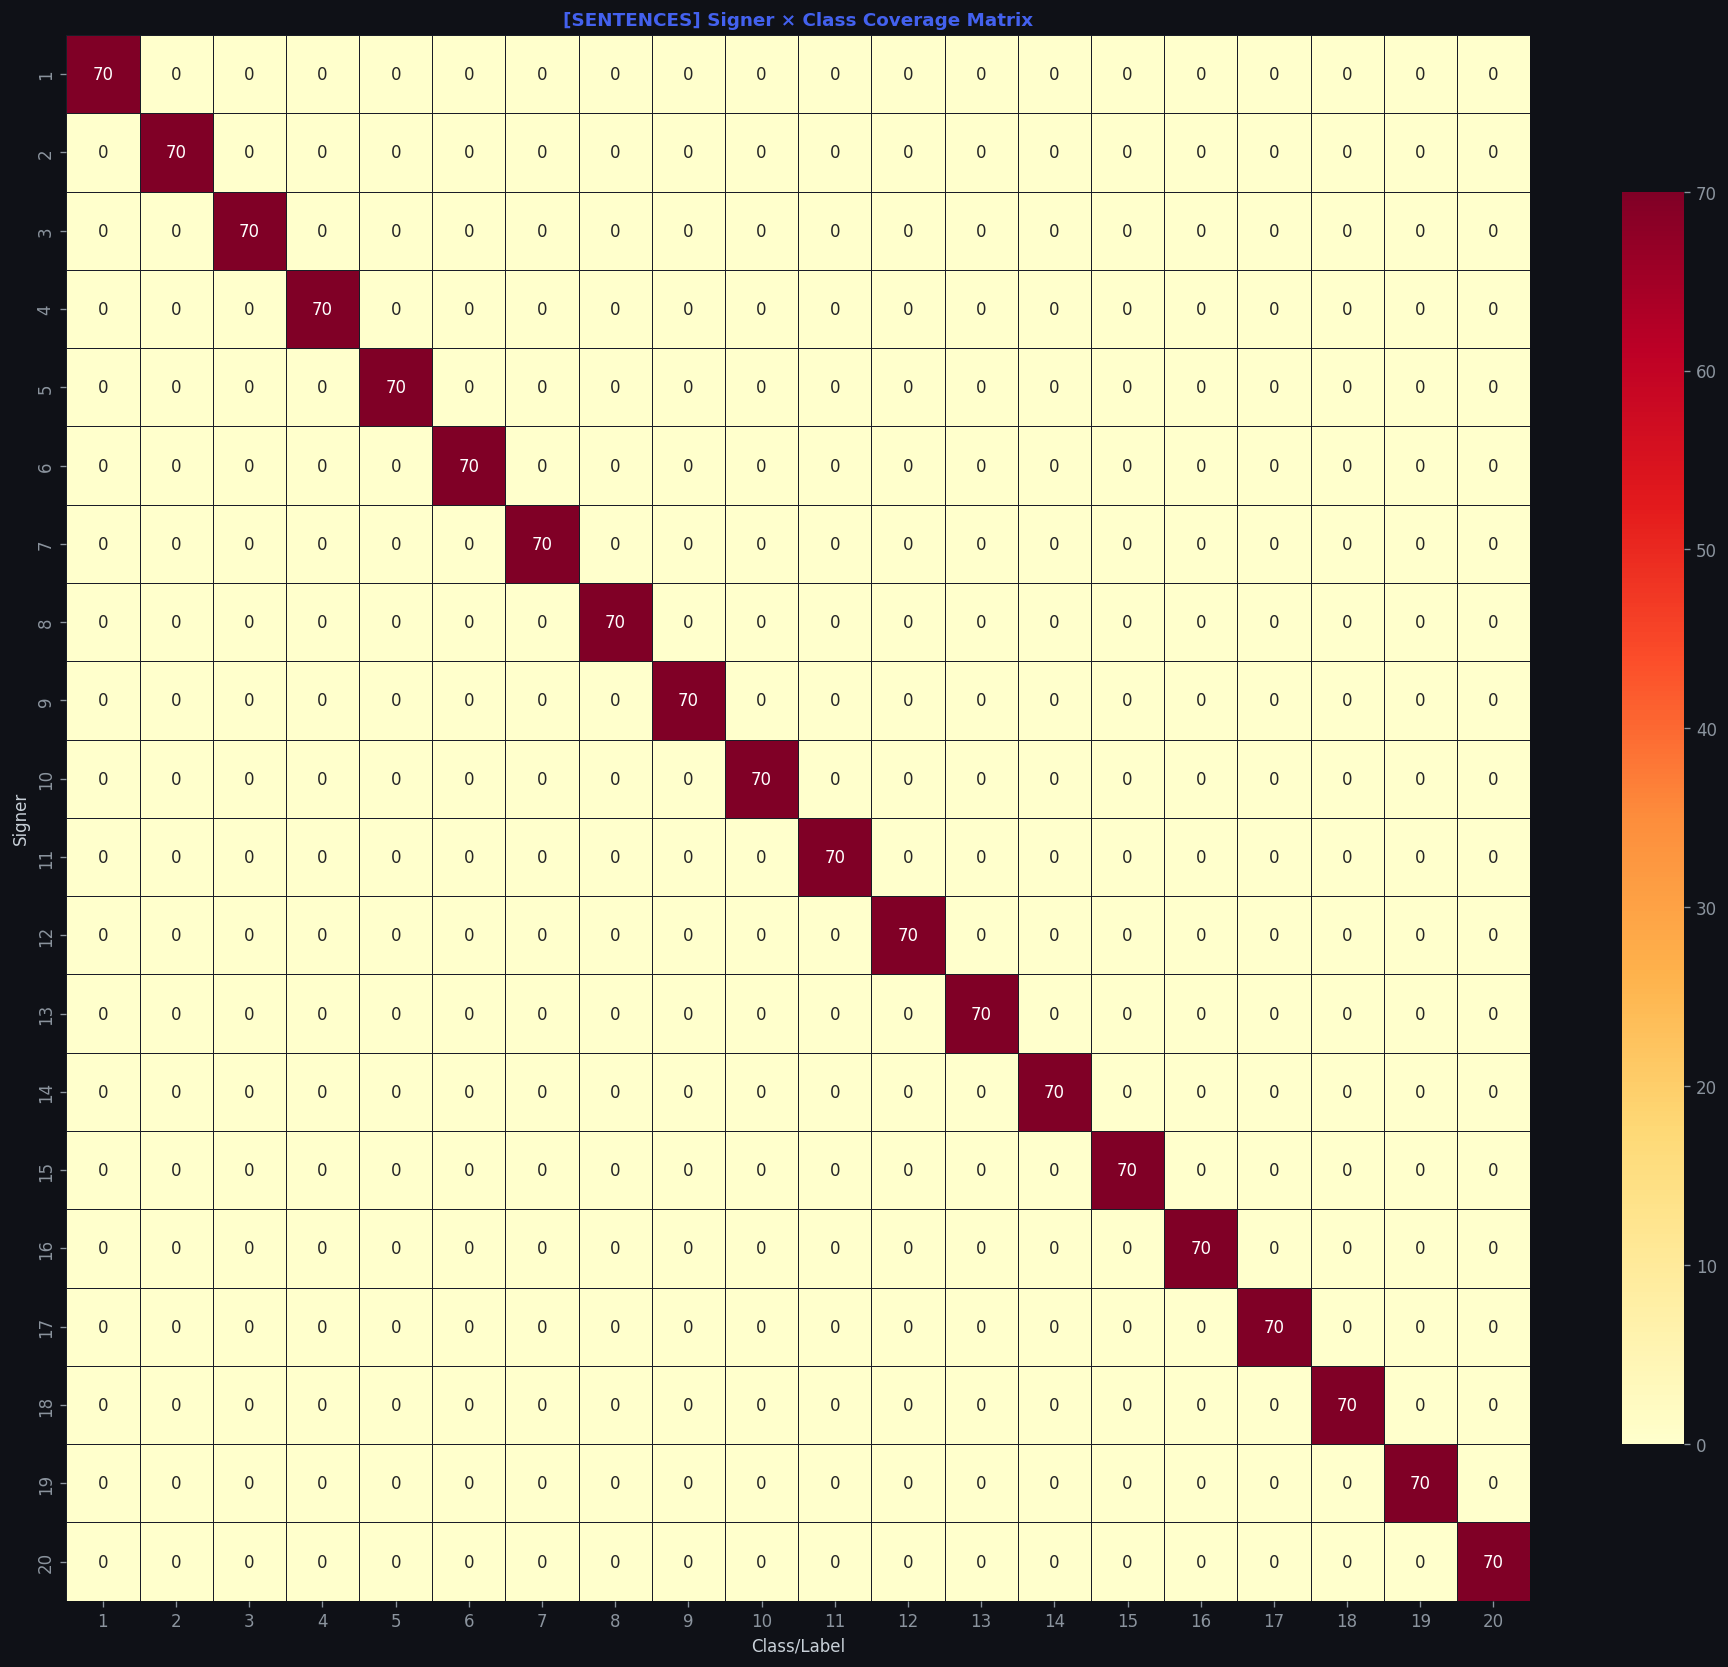

In [27]:
datasets_with_signer = {n: df for n, df in dfs.items() if signer_cols[n] is not None}

if datasets_with_signer:
    n_plots = len(datasets_with_signer)
    fig, axes = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5))
    if n_plots == 1: axes = [axes]
    fig.suptitle('Sample Distribution per Signer', fontsize=13, fontweight='bold')

    for ax, (name, df) in zip(axes, datasets_with_signer.items()):
        scol  = signer_cols[name]
        svc   = df[scol].value_counts().sort_values(ascending=True)
        colors_bar = plt.cm.plasma(np.linspace(0.2, 0.9, len(svc)))
        ax.barh(svc.index.astype(str), svc.values, color=colors_bar, edgecolor='none')
        ax.set_title(f'{name.upper()}\n({df[scol].nunique()} signers)',
                     color=PALETTE[name], fontweight='bold')
        ax.set_xlabel('Jumlah Sample')
        ax.set_ylabel('Signer ID')
        ax.grid(axis='x', alpha=0.4)
        for i, v in enumerate(svc.values):
            ax.text(v + 0.3, i, str(v), va='center', fontsize=8, color='#c9d1d9')

    plt.tight_layout()
    plt.savefig('eda_05_signer_distribution.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

    # ── Per-signer class coverage ─────────────────────────────────────────────
    print('\n── Signer Coverage per Class (heatmap) ────────────────────────────')
    for name, df in datasets_with_signer.items():
        scol = signer_cols[name]
        lcol = label_cols[name]
        n_classes_check = df[lcol].nunique()
        if n_classes_check <= 50:   # hanya untuk dataset kelas kecil
            pivot = df.groupby([scol, lcol]).size().unstack(fill_value=0)
            fig2, ax2 = plt.subplots(figsize=(min(20, n_classes_check*0.7 + 2),
                                              df[scol].nunique() * 0.6 + 2))
            sns.heatmap(pivot, ax=ax2, cmap='YlOrRd', linewidths=0.3,
                        linecolor='#1a1d27', cbar_kws={'shrink': 0.8},
                        annot=(n_classes_check <= 30))
            ax2.set_title(f'[{name.upper()}] Signer × Class Coverage Matrix',
                          fontsize=11, fontweight='bold', color=PALETTE[name])
            ax2.set_xlabel('Class/Label')
            ax2.set_ylabel('Signer')
            plt.tight_layout()
            plt.savefig(f'eda_06_signer_class_heatmap_{name}.png',
                        bbox_inches='tight', facecolor='#0f1117')
            plt.show()
        else:
            print(f'  [{name}] Terlalu banyak kelas ({n_classes_check}) untuk heatmap — skip')
else:
    print('ℹ️  Kolom signer tidak ditemukan di semua dataset.')

## **6. Frame Count / Video Length Analysis**

In [28]:
# ── Deteksi kolom frame count ─────────────────────────────────────────────────
FRAME_COL_CANDIDATES = ['frame_count', 'frames', 'n_frames', 'num_frames',
                         'length', 'duration', 'total_frames', 'video_length']

frame_cols = {}
for name, df in dfs.items():
    found = [c for c in df.columns if any(fc in c.lower() for fc in FRAME_COL_CANDIDATES)]
    frame_cols[name] = found[0] if found else None
    print(f'  [{name:10s}] → frame column: {frame_cols[name] if frame_cols[name] else "NOT FOUND"}')

  [alphabet  ] → frame column: duration
  [number    ] → frame column: duration
  [affix     ] → frame column: duration
  [sentences ] → frame column: duration


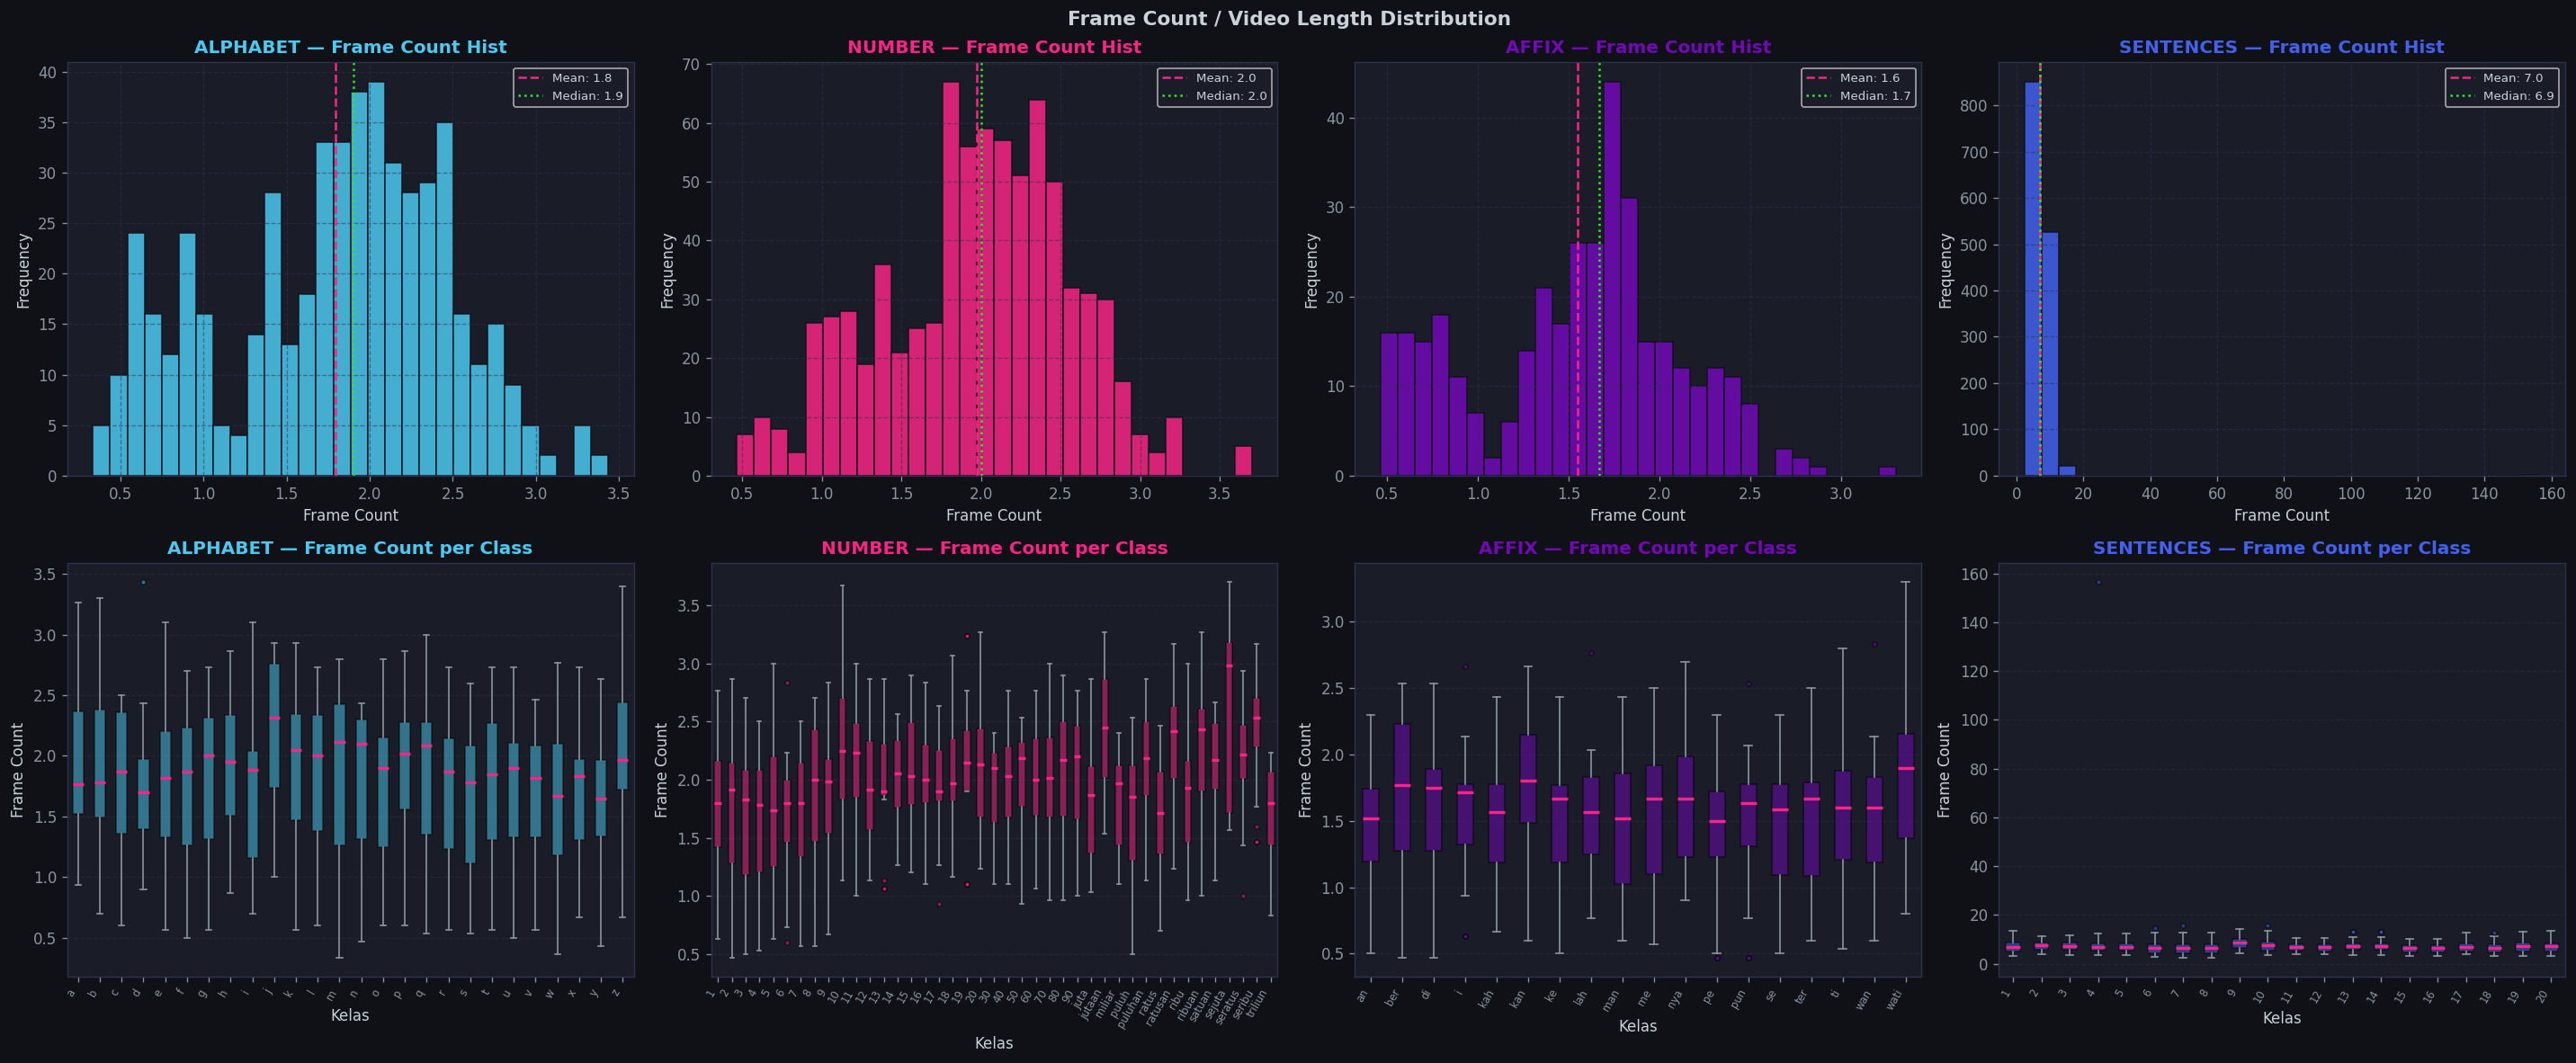


── Frame Count Descriptive Statistics ──────────────────────────────


,alphabet,number,affix,sentences
count,520.00,776.00,360.00,1400.00
mean,1.79,1.97,1.55,7.04
std,0.67,0.60,0.57,4.56
min,0.33,0.47,0.47,2.37
25%,1.36,1.57,1.19,5.13
50%,1.90,2.00,1.67,6.87
75%,2.27,2.40,1.88,8.43
max,3.43,3.70,3.30,156.47


In [35]:
datasets_with_frames = {n: df for n, df in dfs.items() if frame_cols[n] is not None}

if datasets_with_frames:
    n_plots = len(datasets_with_frames)
    fig, axes = plt.subplots(2, n_plots, figsize=(6 * n_plots, 10))
    if n_plots == 1: axes = axes.reshape(2, 1)
    fig.suptitle('Frame Count / Video Length Distribution', fontsize=13, fontweight='bold')

    for col_idx, (name, df) in enumerate(datasets_with_frames.items()):
        fcol = frame_cols[name]
        data = df[fcol].dropna()
        color = PALETTE[name]

        # ── Histogram ────────────────────────────────────────────────────────
        ax_hist = axes[0][col_idx]
        ax_hist.hist(data, bins=30, color=color, edgecolor='#0f1117', alpha=0.85)
        ax_hist.axvline(data.mean(),   color='#f72585', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.1f}')
        ax_hist.axvline(data.median(), color="#2aec18", linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.1f}')
        ax_hist.set_title(f'{name.upper()} — Frame Count Hist', color=color, fontweight='bold')
        ax_hist.set_xlabel('Frame Count')
        ax_hist.set_ylabel('Frequency')
        ax_hist.legend(fontsize=8)
        ax_hist.grid(True)

        # ── Boxplot per class ─────────────────────────────────────────────────
        ax_box = axes[1][col_idx]
        lcol   = label_cols[name]
        classes = df[lcol].unique()
        box_data = [df[df[lcol] == c][fcol].dropna().values for c in classes]
        bp = ax_box.boxplot(box_data, patch_artist=True,
                             medianprops={'color': '#f72585', 'linewidth': 2},
                             whiskerprops={'color': '#8b949e'},
                             capprops={'color': '#8b949e'},
                             flierprops={'marker': 'o', 'markerfacecolor': color,
                                         'markersize': 3, 'alpha': 0.5})
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        ax_box.set_title(f'{name.upper()} — Frame Count per Class', color=color, fontweight='bold')
        ax_box.set_xlabel('Kelas')
        ax_box.set_ylabel('Frame Count')
        ax_box.set_xticklabels(classes, rotation=60, ha='right', fontsize=7)
        ax_box.grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.savefig('eda_07_frame_count.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

    # ── Descriptive stats frame count ─────────────────────────────────────────
    print('\n── Frame Count Descriptive Statistics ──────────────────────────────')
    frame_stats = pd.DataFrame({
        name: df[frame_cols[name]].describe()
        for name, df in datasets_with_frames.items()
    })
    display(frame_stats.round(2))
else:
    print('ℹ️  Kolom frame count tidak ditemukan.')

## **7. Train / Validation / Test Split Analysis**

In [30]:
# ── Deteksi kolom split ───────────────────────────────────────────────────────
SPLIT_COL_CANDIDATES = ['split', 'subset', 'partition', 'set', 'fold', 'phase']

split_cols = {}
for name, df in dfs.items():
    found = [c for c in df.columns if any(sc in c.lower() for sc in SPLIT_COL_CANDIDATES)]
    split_cols[name] = found[0] if found else None
    print(f'  [{name:10s}] → split column: {split_cols[name] if split_cols[name] else "NOT FOUND"}')

  [alphabet  ] → split column: NOT FOUND
  [number    ] → split column: NOT FOUND
  [affix     ] → split column: NOT FOUND
  [sentences ] → split column: NOT FOUND


In [31]:
datasets_with_split = {n: df for n, df in dfs.items() if split_cols[n] is not None}

if datasets_with_split:
    n_plots = len(datasets_with_split)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    if n_plots == 1: axes = [axes]
    fig.suptitle('Train / Validation / Test Split Distribution', fontsize=13, fontweight='bold')

    split_colors = {'train': '#4cc9f0', 'val': '#f72585', 'test': '#7209b7',
                    'validation': '#f72585', 'dev': '#4361ee'}

    for ax, (name, df) in zip(axes, datasets_with_split.items()):
        scol = split_cols[name]
        vc   = df[scol].value_counts()
        colors_pie = [split_colors.get(str(k).lower(), '#8b949e') for k in vc.index]
        wedges, texts, autotexts = ax.pie(
            vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=colors_pie,
            wedgeprops={'edgecolor': '#0f1117', 'linewidth': 2},
            textprops={'color': '#c9d1d9', 'fontsize': 10}
        )
        for at in autotexts:
            at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
        ax.set_title(f'{name.upper()}\nTotal: {len(df):,}', color=PALETTE[name], fontweight='bold')

        # Annotasi jumlah absolut
        for i, (label, count) in enumerate(vc.items()):
            print(f'  [{name}] {label:12s}: {count:,} samples')

    plt.tight_layout()
    plt.savefig('eda_08_split_distribution.png', bbox_inches='tight', facecolor='#0f1117')
    plt.show()

    # ── Class balance per split ───────────────────────────────────────────────
    print('\n── Class Balance per Split ─────────────────────────────────────────')
    for name, df in datasets_with_split.items():
        scol = split_cols[name]
        lcol = label_cols[name]
        split_class = df.groupby([scol, lcol]).size().unstack(fill_value=0)
        print(f'\n  [{name.upper()}] Samples per split per class (describe):')
        display(split_class.T.describe().round(2))
else:
    print('ℹ️  Kolom split tidak ditemukan. Akan perlu dibuat manual.')
    print('   Rekomendasi split: 80% train / 10% val / 10% test (stratified by class + signer)')

ℹ️  Kolom split tidak ditemukan. Akan perlu dibuat manual.
   Rekomendasi split: 80% train / 10% val / 10% test (stratified by class + signer)


## **8. Combined Dataset: Full Picture**

In [32]:
# ── Gabungkan semua metadata (shared columns saja) ────────────────────────────
# Normalisasi nama kolom label menjadi 'label' di semua df
dfs_normalized = []
for name, df in dfs.items():
    df_copy = df.copy()
    
    # [SOLUSI] Hapus kolom duplikat yang mungkin sudah ada sebelum rename
    df_copy = df_copy.loc[:, ~df_copy.columns.duplicated()]
    
    df_copy['gesture_type'] = gesture_type_map.get(name, 'Unknown')

    # Rename label column ke standar
    if label_cols[name] != 'label':
        df_copy = df_copy.rename(columns={label_cols[name]: 'label'})

    # Rename frame col ke standar jika ada
    if frame_cols.get(name) and frame_cols[name] != 'frame_count':
        df_copy = df_copy.rename(columns={frame_cols[name]: 'frame_count'})
        
    # [SOLUSI TAMBAHAN] Antisipasi jika setelah di-rename malah memicu nama kolom duplikat
    df_copy = df_copy.loc[:, ~df_copy.columns.duplicated()]

    dfs_normalized.append(df_copy)

# Sekarang gabungkan dengan aman
df_all = pd.concat(dfs_normalized, ignore_index=True)
print(f'Combined dataset shape: {df_all.shape}')
print(f'Gesture types: {df_all["gesture_type"].value_counts().to_dict()}')
print(f'Total unique classes: {df_all["label"].nunique()}')
display(df_all.head())

Combined dataset shape: (3056, 14)
Gesture types: {'Dynamic': 1760, 'Static': 1296}
Total unique classes: 104


,signer,label,filepath,frame_count,bit_rate,width,height,codec,frame_rate,file_size_bytes,__source__,gesture_type,no_sentence,expression
0,1.0,a,sibi-dataset-dib\alphabet\a\signer-1-alphabet-...,1.966667,1111761,800,800,h264,30,273308,alphabet,Static,NaN,NaN
1,2.0,a,sibi-dataset-dib\alphabet\a\signer-2-alphabet-...,1.433333,1344156,900,900,h264,30,240828,alphabet,Static,NaN,NaN
2,3.0,a,sibi-dataset-dib\alphabet\a\signer-3-alphabet-...,1.500000,1029946,800,800,h264,30,193115,alphabet,Static,NaN,NaN
3,4.0,a,sibi-dataset-dib\alphabet\a\signer-4-alphabet-...,1.700000,6589284,800,800,h264,30,1400223,alphabet,Static,NaN,NaN
4,5.0,a,sibi-dataset-dib\alphabet\a\signer-5-alphabet-...,1.833333,6314780,800,800,h264,30,1447137,alphabet,Static,NaN,NaN


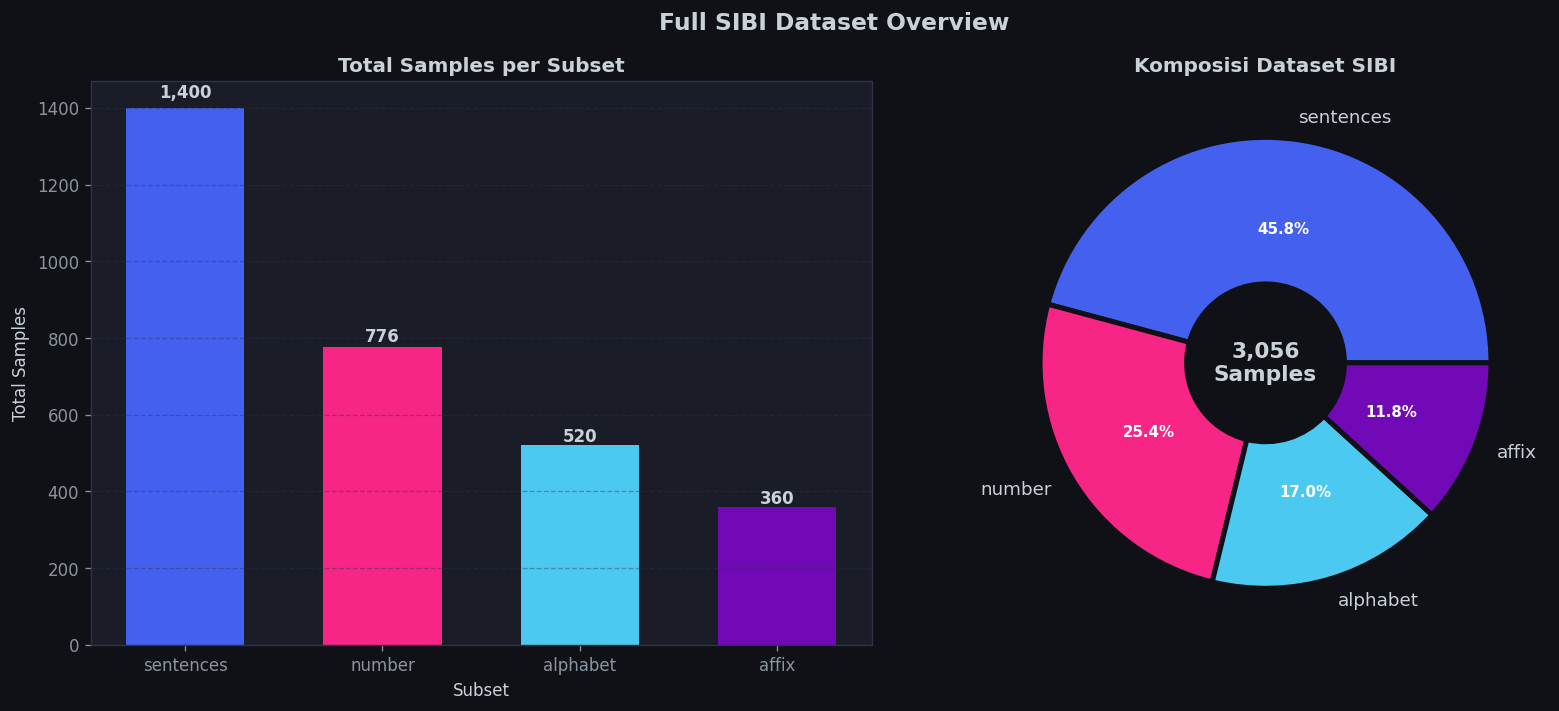

In [33]:
# ── Full overview bar chart ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Full SIBI Dataset Overview', fontsize=14, fontweight='bold')

# Samples per source
source_count = df_all['__source__'].value_counts()
colors_bar   = [PALETTE[s] for s in source_count.index]
axes[0].bar(source_count.index, source_count.values, color=colors_bar, edgecolor='none', width=0.6)
for i, (src, cnt) in enumerate(source_count.items()):
    axes[0].text(i, cnt * 1.02, f'{cnt:,}', ha='center', fontsize=10, color='#c9d1d9', fontweight='bold')
axes[0].set_title('Total Samples per Subset', fontweight='bold')
axes[0].set_xlabel('Subset')
axes[0].set_ylabel('Total Samples')
axes[0].grid(axis='y', alpha=0.4)

# Sample % composition donut
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    source_count.values,
    labels=source_count.index,
    autopct='%1.1f%%',
    colors=[PALETTE[s] for s in source_count.index],
    wedgeprops={'edgecolor': '#0f1117', 'linewidth': 3, 'width': 0.65},
    textprops={'color': '#c9d1d9', 'fontsize': 11}
)
for at in autotexts: at.set_fontsize(9); at.set_color('white'); at.set_fontweight('bold')
# Center text
ax2.text(0, 0, f'{len(df_all):,}\nSamples', ha='center', va='center',
          fontsize=13, color='#c9d1d9', fontweight='bold')
ax2.set_title('Komposisi Dataset SIBI', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_09_full_overview.png', bbox_inches='tight', facecolor='#0f1117')
plt.show()

## **9. ST-GCN Readiness Assessment: Window Size Recommendation**

In [34]:
# Berdasarkan paper Al-Hammadi et al. (2022):
# Window size di-set berdasarkan rata-rata frame per video per dataset

print('='*65)
print('  ST-GCN INPUT PARAMETER RECOMMENDATION')
print('  (Based on Al-Hammadi et al. 2022 methodology)')
print('='*65)

stgcn_params = []

for name, df in dfs.items():
    fcol = frame_cols.get(name)
    if fcol:
        mean_frames  = int(df[fcol].mean())
        # Paper: window size = rata-rata frame per video, di-round ke kelipatan 4
        window_size  = max(16, round(mean_frames / 4) * 4)
    else:
        mean_frames  = 'N/A'
        window_size  = 32  # default dari paper untuk static gestures

    n_classes = df[label_cols[name]].nunique()
    g_type    = gesture_type_map.get(name)

    stgcn_params.append({
        'Subset'          : name,
        'Gesture Type'    : g_type,
        'Num Classes'     : n_classes,
        'Total Samples'   : len(df),
        'Avg Frames'      : mean_frames,
        'Rec. Window Size': window_size,
        'Num Nodes'       : 25,   # Paper: 25 MediaPipe landmarks
        'Input Shape'     : f'(3, {window_size}, 25)',  # (C, T, V)
    })

    print(f'\n  [{name.upper()}]')
    print(f'    Gesture Type      : {g_type}')
    print(f'    Num Classes       : {n_classes}')
    print(f'    Total Samples     : {len(df):,}')
    print(f'    Avg Frame Count   : {mean_frames}')
    print(f'    Rec. Window Size  : T = {window_size}')
    print(f'    Graph Nodes (V)   : 25 (MediaPipe selected landmarks)')
    print(f'    Input Tensor Shape: (batch, 3, {window_size}, 25)')
    print(f'    → C=3 (x,y,z coords), T={window_size} (frames), V=25 (nodes)')

print('\n')
display(pd.DataFrame(stgcn_params).set_index('Subset'))

  ST-GCN INPUT PARAMETER RECOMMENDATION
  (Based on Al-Hammadi et al. 2022 methodology)

  [ALPHABET]
    Gesture Type      : Static
    Num Classes       : 26
    Total Samples     : 520
    Avg Frame Count   : 1
    Rec. Window Size  : T = 16
    Graph Nodes (V)   : 25 (MediaPipe selected landmarks)
    Input Tensor Shape: (batch, 3, 16, 25)
    → C=3 (x,y,z coords), T=16 (frames), V=25 (nodes)

  [NUMBER]
    Gesture Type      : Static
    Num Classes       : 41
    Total Samples     : 776
    Avg Frame Count   : 1
    Rec. Window Size  : T = 16
    Graph Nodes (V)   : 25 (MediaPipe selected landmarks)
    Input Tensor Shape: (batch, 3, 16, 25)
    → C=3 (x,y,z coords), T=16 (frames), V=25 (nodes)

  [AFFIX]
    Gesture Type      : Dynamic
    Num Classes       : 18
    Total Samples     : 360
    Avg Frame Count   : 1
    Rec. Window Size  : T = 16
    Graph Nodes (V)   : 25 (MediaPipe selected landmarks)
    Input Tensor Shape: (batch, 3, 16, 25)
    → C=3 (x,y,z coords), T=16 (fr

,Gesture Type,Num Classes,Total Samples,Avg Frames,Rec. Window Size,Num Nodes,Input Shape
Subset,,,,,,,
alphabet,Static,26,520,1,16,25,"(3, 16, 25)"
number,Static,41,776,1,16,25,"(3, 16, 25)"
affix,Dynamic,18,360,1,16,25,"(3, 16, 25)"
sentences,Dynamic,20,1400,7,16,25,"(3, 16, 25)"
